In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import torch.nn.functional as F

In [4]:
class CLAHE(object):

    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):

        img = np.array(img)

        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )

        img = clahe.apply(img)

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(img)

In [5]:
train_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
val_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
train_dataset = ImageFolder(
    "../archive/chest_xray/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    "../archive/chest_xray/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    "../archive/chest_xray/test",
    transform=val_transform
)

In [8]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np

In [9]:
train_labels = [label for _, label in train_dataset.samples]

print(Counter(train_labels))

Counter({1: 3875, 0: 1341})


In [10]:
class_counts = np.bincount(train_labels)

class_weights = 1.0 / class_counts

sample_weights = class_weights[train_labels]

In [11]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

In [80]:
images, labels = next(iter(train_loader))

print(labels)

d:\ai-based-medical-imaging\.venv\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


tensor([0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0])


In [81]:
test_dataset

Dataset ImageFolder
    Number of datapoints: 624
    Root location: ../archive/chest_xray/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [82]:
images.shape

torch.Size([16, 3, 224, 224])

In [91]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

image = images[0].cpu()

# Denormalize
image = image * std + mean

# Keep values in valid display range
image = image.clamp(0, 1)

In [93]:
image.shape

torch.Size([3, 224, 224])

In [94]:
import torch
patch_size = 16
patches = image.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


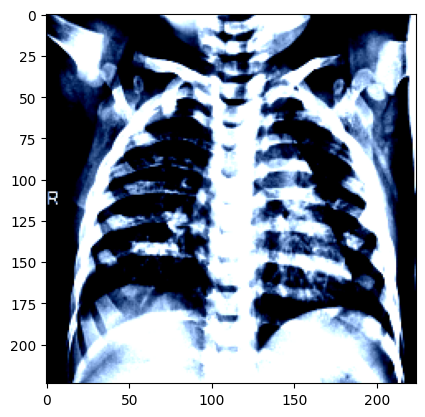

In [95]:
plt.imshow(images[0].permute(1, 2, 0))

In [96]:
print(patches.shape)

torch.Size([3, 14, 14, 16, 16])


In [97]:
images[0].shape

torch.Size([3, 224, 224])

In [ ]:
B, C, H_patches, W_patches, P, _ = patches.shape

patches = patches.permute(
    0, 2, 3, 1, 4, 5
)

patches = patches.reshape(
    B,
    H_patches * W_patches,
    C * P * P
)

print(patches.shape)

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 5 is not equal to len(dims) = 6

In [98]:
patches = patches.reshape(-1, 3, patch_size, patch_size)

In [99]:
patches.shape

torch.Size([196, 3, 16, 16])

In [ ]:
patches.reshape(3, 16, 16)

In [47]:
patches.shape

torch.Size([16, 196, 768])

In [100]:
patches[0].shape

torch.Size([3, 16, 16])

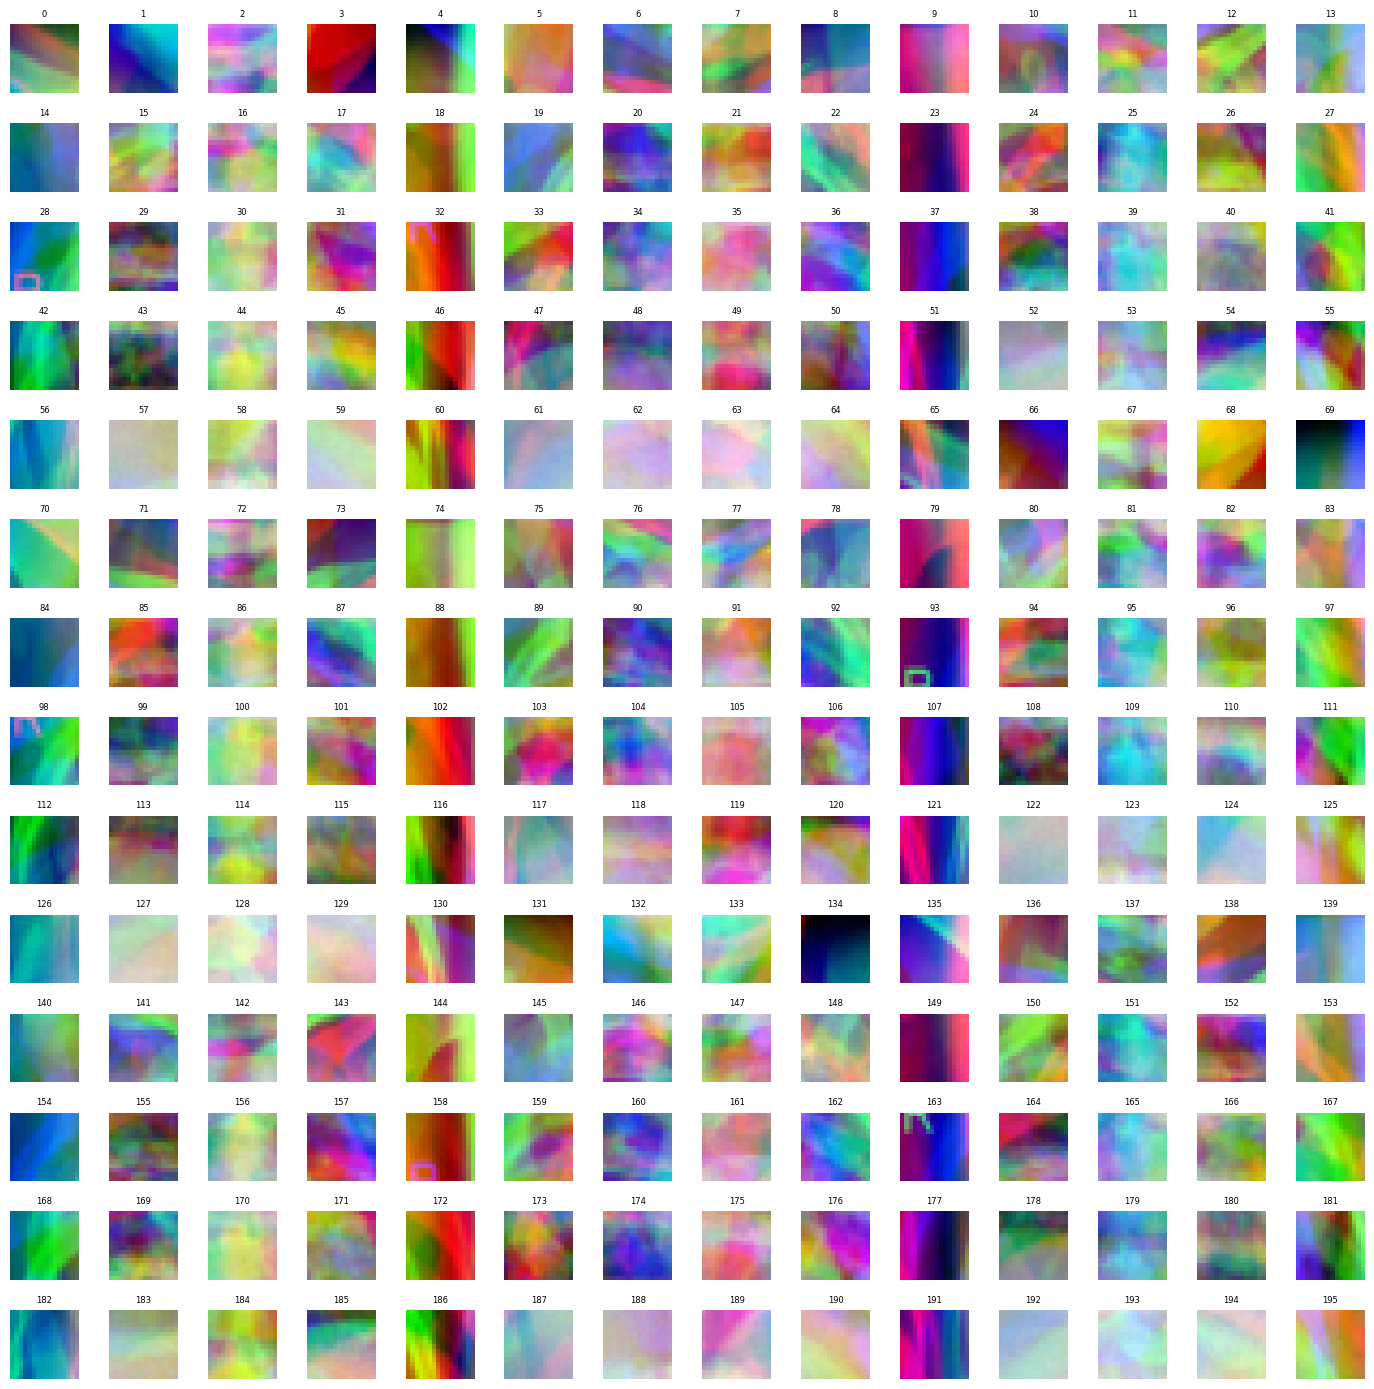

In [ ]:
fig, axes = plt.subplots(14, 14, figsize=(14, 14))

for i, ax in enumerate(axes.flat):
    patch = patches[i].permute(1, 2, 0).cpu().numpy()

    ax.imshow(patch, cmap="gray")
    ax.set_title(str(i), fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

d:\ai-based-medical-imaging\.venv\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Patch tensor shape: torch.Size([196, 3, 16, 16])
Normalized image range: -2.1007792949676514 2.6051416397094727
Patch 0 shape: (16, 16)


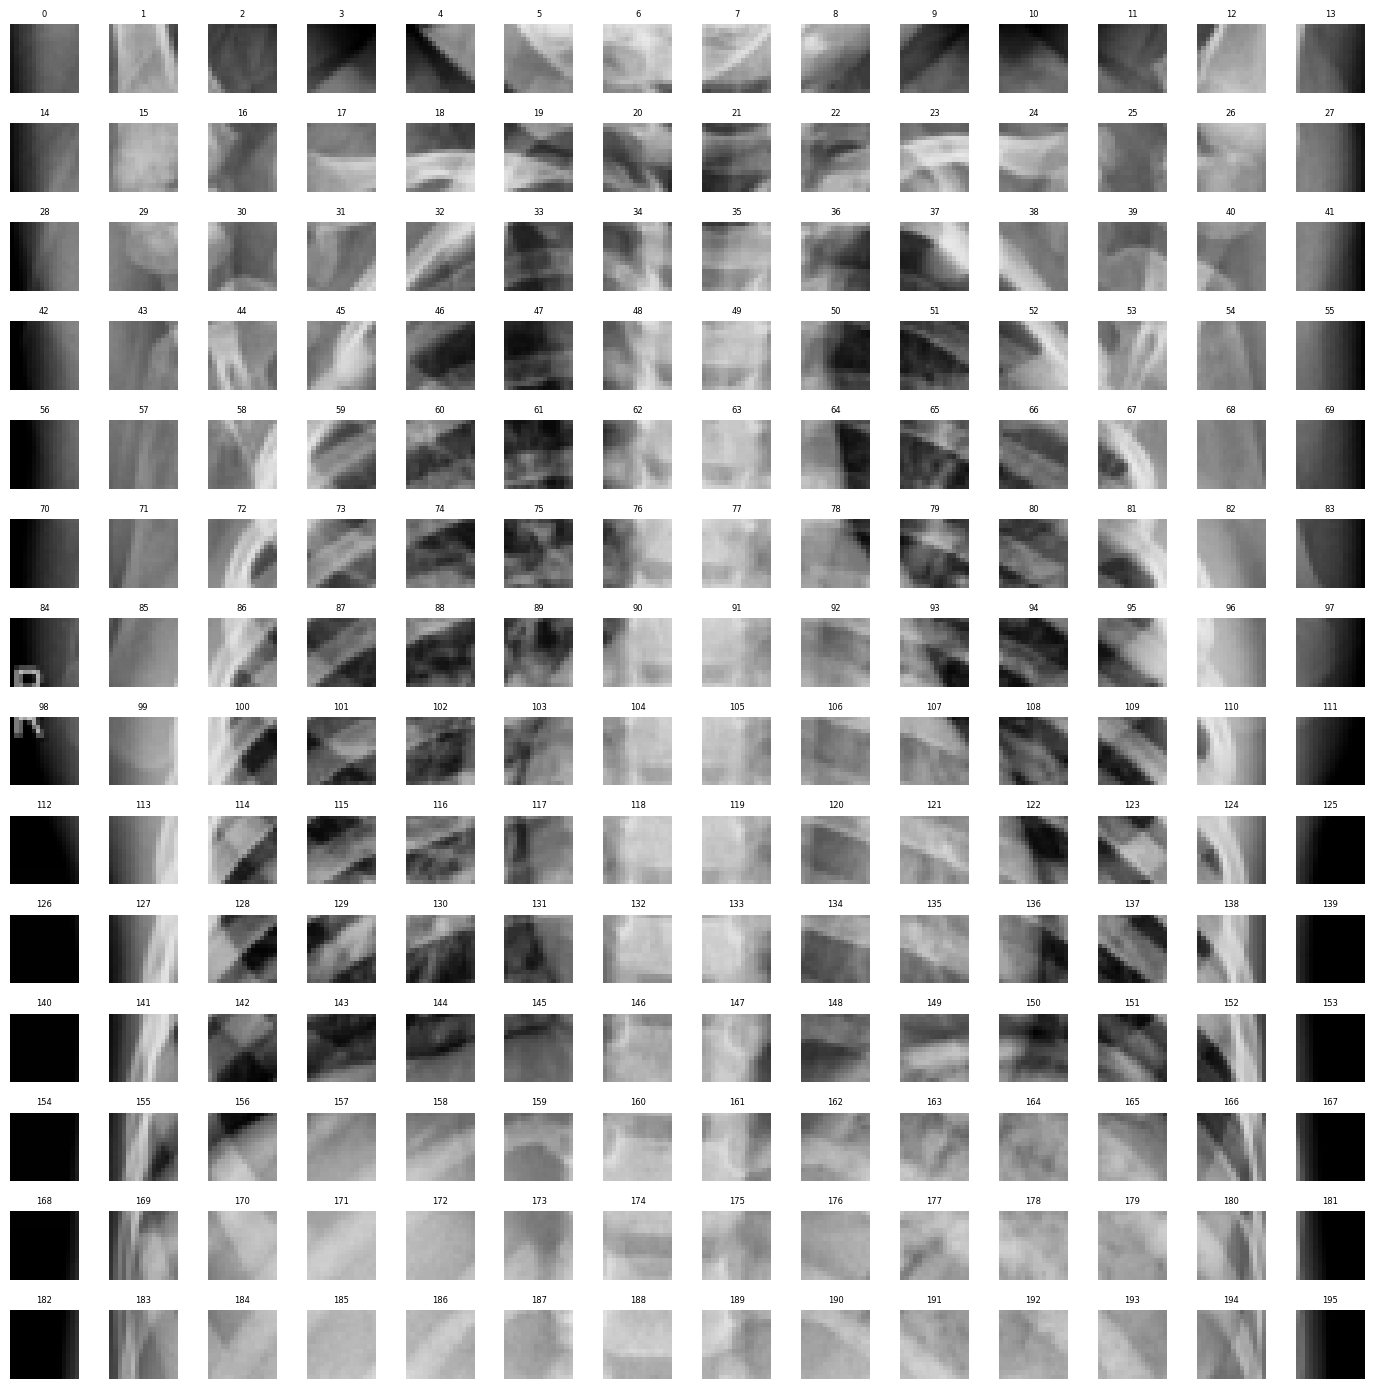

In [102]:
import torch
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# First image
image = images[0]   # [3, 224, 224]

patch_size = 16

# --------------------------------------------------
# 1. Create 16x16 patches
# --------------------------------------------------
patches = (
    image
    .unfold(1, patch_size, patch_size)
    .unfold(2, patch_size, patch_size)
)

# [3, 14, 14, 16, 16]
patches = patches.permute(1, 2, 0, 3, 4)

# [196, 3, 16, 16]
patches = patches.reshape(-1, 3, patch_size, patch_size)

print("Patch tensor shape:", patches.shape)

# --------------------------------------------------
# 2. Calculate grayscale range from normalized image
# --------------------------------------------------
vmin = image.min().item()
vmax = image.max().item()

print("Normalized image range:", vmin, vmax)

# --------------------------------------------------
# 3. Plot patches as GRAYSCALE
# --------------------------------------------------
fig, axes = plt.subplots(14, 14, figsize=(14, 14))

for i, ax in enumerate(axes.flat):

    # Take only channel 0
    patch = patches[i, 0, :, :]

    # Convert to numpy
    patch = patch.detach().cpu().numpy()

    # IMPORTANT: patch must be 2D
    print(f"Patch {i} shape:", patch.shape) if i == 0 else None

    ax.imshow(
        patch,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(str(i), fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()